Add `%load_ext cudf.pandas` before importing pandas to speed up operations using GPU

In [ ]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np

# Randomly generated dataset of parking violations-
# Define the number of rows
num_rows = 1000000

states = ["NY", "NJ", "CA", "TX"]
violations = ["Double Parking", "Expired Meter", "No Parking",
              "Fire Hydrant", "Bus Stop"]
vehicle_types = ["SUBN", "SDN"]

# Create a date range
start_date = "2022-01-01"
end_date = "2022-12-31"
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Generate random data
data = {
    "Registration State": np.random.choice(states, size=num_rows),
    "Violation Description": np.random.choice(violations, size=num_rows),
    "Vehicle Body Type": np.random.choice(vehicle_types, size=num_rows),
    "Issue Date": np.random.choice(dates, size=num_rows),
    "Ticket Number": np.random.randint(1000000000, 9999999999, size=num_rows)
}

# Create a DataFrame
df = pd.DataFrame(data)

# Which parking violation is most commonly committed by vehicles from various U.S states?

(df[["Registration State", "Violation Description"]]  # get only these two columns
 .value_counts()  # get the count of offences per state and per type of offence
 .groupby("Registration State")  # group by state
 .head(1)  # get the first row in each group (the type of offence with the largest count)
 .sort_index()  # sort by state name
 .reset_index()
)

/usr/local/lib/python3.12/dist-packages/cudf/utils/gpu_utils.py:75: UserWarning: Failed to dlopen libcuda.so.1
  warnings.warn(str(e))
/usr/local/lib/python3.12/dist-packages/cudf/pandas/__init__.py:64: UserWarning: Function "cuInit" not found
  warnings.warn(str(e))


,Registration State,Violation Description,count
0,CA,Fire Hydrant,50103
1,NJ,Double Parking,50183
2,NY,Fire Hydrant,50267
3,TX,Bus Stop,50204


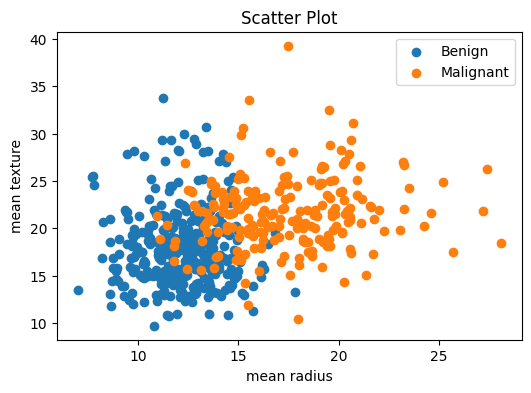

Accuracy: 0.9473684210526315

Classification Report:
               precision    recall  f1-score   support

      Benign       0.92      1.00      0.96        71
   Malignant       1.00      0.86      0.93        43

    accuracy                           0.95       114
   macro avg       0.96      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



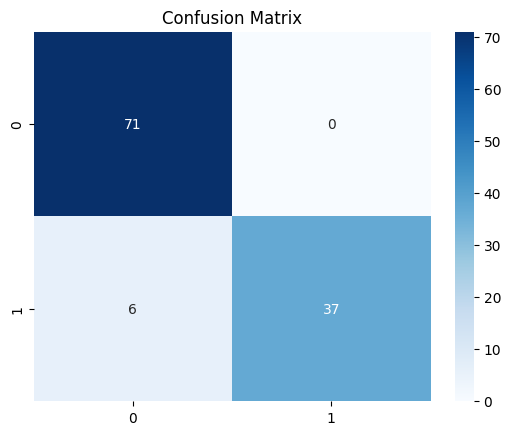

In [ ]:
# 1) استيراد المكتبات
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

# 2) تحميل البيانات
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # 1 = حميد / 0 = خبيث
df['target'] = df['target'].map({1: 'Benign', 0: 'Malignant'})

# عرض أول 5 صفوف
df.head()

# 3) رسم Scatter Plot باستخدام ميزتين فقط
plt.figure(figsize=(6,4))
for label in ['Benign', 'Malignant']:
    subset = df[df['target'] == label]
    plt.scatter(subset['mean radius'], subset['mean texture'], label=label)
plt.xlabel('mean radius')
plt.ylabel('mean texture')
plt.title('Scatter Plot')
plt.legend()
plt.show()

# 4) تجهيز البيانات
X = df[data.feature_names]
y = df['target']

# 5) تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6) تدريب نموذج SVM
model = SVC(kernel='rbf', C=2, gamma='scale')
model.fit(X_train, y_train)

# 7) التنبؤ
y_pred = model.predict(X_test)

# 8) طباعة النتائج
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 9) مصفوفة الالتباس
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
import gradio as gr

# نختار 5 ميزات بس للواجهة (عشان تكون بسيطة وما نتعب المستخدم)
def predict_tumor(mean_radius, mean_texture, mean_perimeter, mean_area, mean_smoothness):
    sample = [[mean_radius, mean_texture, mean_perimeter, mean_area, mean_smoothness] + [0]*(30-5)]
    pred = model.predict(sample)[0]
    if pred == 'Benign':
        return "✅ النتيجة: الورم حميد"
    else:
        return "⚠️ النتيجة: الورم خبيث"

inputs = [
    gr.Number(label="mean radius"),
    gr.Number(label="mean texture"),
    gr.Number(label="mean perimeter"),
    gr.Number(label="mean area"),
    gr.Number(label="mean smoothness")
]

gr.Interface(
    fn=predict_tumor,
    inputs=inputs,
    outputs="text",
    title="Breast Cancer Tumor Classifier (SVM)",
    description="ادخلي قيم خصائص الورم وسيتم التنبؤ إذا كان حميد أو خبيث"
).launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://64ea5edd918ef440a6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr
import pandas as pd

# نستخدم نفس X.columns حتى تكون الأعمدة متطابقة
selected_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']

def predict_tumor(mean_radius, mean_texture, mean_perimeter, mean_area, mean_smoothness):
    # إنشاء عينة بيانات بالشكل الصحيح
    input_data = pd.DataFrame([[mean_radius, mean_texture, mean_perimeter, mean_area, mean_smoothness]],
                              columns=selected_features)

    # ندمج العينة مع القيم المتوسطة لباقي الأعمدة حتى ما يصير نقص
    for col in X.columns:
        if col not in selected_features:
            input_data[col] = X[col].mean()

    pred = model.predict(input_data)[0]

    if pred == 'Benign':
        return "✅ النتيجة: الورم حميد"
    else:
        return "⚠️ النتيجة: الورم خبيث"

inputs = [
    gr.Number(label="mean radius"),
    gr.Number(label="mean texture"),
    gr.Number(label="mean perimeter"),
    gr.Number(label="mean area"),
    gr.Number(label="mean smoothness")
]

gr.Interface(
    fn=predict_tumor,
    inputs=inputs,
    outputs="text",
    title="Breast Cancer Tumor Classifier (SVM)",
    description="أدخلي القيم وسيتم التنبؤ إذا كان الورم حميد أو خبيث"
).launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://caa58cab69c6946570.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
